# Importing and Dataset Preparation

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Gpytorch library starts

import gpytorch
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.means import ConstantMean
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood

from torch.nn import Module

import warnings
warnings.filterwarnings("ignore", category=gpytorch.utils.warnings.GPInputWarning)

## Gpytorch library ends

from torch.utils.data import DataLoader, TensorDataset

import tqdm
from tqdm.notebook import tqdm

import time
import gc
import psutil
import os
import math

#%matplotlib inline
#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2

torch.autograd.set_detect_anomaly(True)

# GPU support
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Set random seed for reproducibility
torch.manual_seed(42)

### New Dataset Starts Airfoil Self-Noise dataset 

# URL of the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat"

# Column names from UCI site
columns = [
    "Frequency", "Angle_of_attack", "Chord_length",
    "Free_stream_velocity", "Suction_side_displacement_thickness",
    "Sound_pressure_level"  # This is the target
]

# Load dataset
df = pd.read_csv(url, sep='\t', header=None, names=columns)

# Split into features and target
X = df.drop(columns=["Sound_pressure_level"]).values
y = df["Sound_pressure_level"].values

# Normalize features
scaler_X = StandardScaler().fit(X)

scaler_y = StandardScaler().fit(y.reshape(-1, 1))
X = scaler_X.transform(X)
y = scaler_y.transform(y.reshape(-1, 1)).flatten()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
#y_train = torch.tensor(y_train, dtype=torch.float32, device=device).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32, device=device)
#y_test = torch.tensor(y_test, dtype=torch.float32, device=device).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1).to(device)  # (n,)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1).to(device)  # (n,)

Using device: cuda


In [26]:
def safe_tensor(data, dtype=torch.float32, device='cpu', reshape=None):
    if isinstance(data, torch.Tensor):
        tensor = data.detach().clone().to(dtype)
    else:
        tensor = torch.tensor(data, dtype=dtype)

    if reshape is not None:
        tensor = tensor.reshape(*reshape)

    return tensor.to(device)

In [ ]:
print(X_train.shape, X_test.shape) #80-20 split

# Gpytorch Version of Full GPR

In [48]:
# === Model Definition ===

# We will use the simplest form of GP model, exact inference

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=1.5)  
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [49]:
# === Clear Cache and Reset Memory Stats ===  #noise [0.5 already done, now 0.1, 0.01, 0.6, 0.9 test] #stress test on noise is done.
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(device)
start_time = time.time()

# === Initialize Likelihood and Fix Noise ===
likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
likelihood.noise = torch.tensor(0.5, device=device)  # Fixed noise
likelihood.noise_covar.raw_noise.requires_grad = False  # Disable learning

# === Initialize Model ===
model = ExactGPModel(X_train, y_train, likelihood).to(device)

# === Training Mode ===
model.train()
likelihood.train()

# === Optimizer & Marginal Log Likelihood ===
optimizer = torch.optim.Adam([
    {'params': model.parameters()}  # noise won't be updated
], lr=0.01)

mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

# === Training Loop ===
training_iter = 100
for i in range(training_iter):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train)
    loss.backward()
    if i % 10 == 0:
        print(f"Iter {i}/{training_iter} - Loss: {loss.item():.3f} "
              f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():.3f} "
              f"outputscale: {model.covar_module.outputscale.item():.3f} "
              f"noise: {likelihood.noise.item():.3f}")
    optimizer.step()

# === Evaluation ===
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    preds = likelihood(model(X_test.to(device)))
    mu_full = preds.mean.cpu()                     # Predictive mean
    variance_full = preds.variance.cpu()           # Predictive variance 
    # NLL (Negative Marginal Log-Likelihood)
    nll_full = -mll(model(X_train), y_train).item()

# === End Timing and Memory ===
torch.cuda.synchronize()
end_time = time.time()
time_taken = end_time - start_time
peak_memory = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB

# === Print Summary ===
print(f"\n--- GPyTorch Full GP (Training + Inference) ---")
print(f"Total Time             : {time_taken:.2f} seconds")
print(f"Peak GPU Memory        : {peak_memory:.2f} MB")
print(f"Negative Log-Likelihood: {nll_full:.3f}")

Iter 0/100 - Loss: 0.988 lengthscale: 0.693 outputscale: 0.693 noise: 0.500
Iter 10/100 - Loss: 0.964 lengthscale: 0.744 outputscale: 0.645 noise: 0.500
Iter 20/100 - Loss: 0.948 lengthscale: 0.796 outputscale: 0.600 noise: 0.500


Iter 30/100 - Loss: 0.944 lengthscale: 0.848 outputscale: 0.563 noise: 0.500
Iter 40/100 - Loss: 0.938 lengthscale: 0.899 outputscale: 0.534 noise: 0.500
Iter 50/100 - Loss: 0.928 lengthscale: 0.949 outputscale: 0.514 noise: 0.500
Iter 60/100 - Loss: 0.921 lengthscale: 0.996 outputscale: 0.506 noise: 0.500
Iter 70/100 - Loss: 0.925 lengthscale: 1.041 outputscale: 0.504 noise: 0.500
Iter 80/100 - Loss: 0.917 lengthscale: 1.085 outputscale: 0.509 noise: 0.500
Iter 90/100 - Loss: 0.910 lengthscale: 1.127 outputscale: 0.518 noise: 0.500

--- GPyTorch Full GP (Training + Inference) ---
Total Time             : 2.62 seconds
Peak GPU Memory        : 45.17 MB
Negative Log-Likelihood: 0.763


In [50]:
#--RMSE + NLPD + SMSE
# -- Convert predictive mean and variance to NumPy --
mu_full_np = mu_full.cpu().numpy().reshape(-1, 1)
var_full_np = variance_full.cpu().numpy().reshape(-1, 1)

# -- Inverse transform mean and variance --
mu_full_inv = scaler_y.inverse_transform(mu_full_np).flatten()
y_std = scaler_y.scale_[0]
var_full_inv = (var_full_np * (y_std ** 2)).flatten()

# -- Inverse transform y_test and y_train --
y_test_np = y_test.cpu().numpy().reshape(-1, 1)
y_test_inv = scaler_y.inverse_transform(y_test_np).flatten()

y_train_np = y_train.cpu().numpy().reshape(-1, 1)
y_train_inv = scaler_y.inverse_transform(y_train_np).flatten()
y_train_mean = np.mean(y_train_inv)

# -- RMSE --
rmse = np.sqrt(np.mean((mu_full_inv - y_test_inv) ** 2))
print(f"RMSE: {rmse:.4f}")

# -- NLPD --
nlpd = 0.5 * np.log(2 * np.pi * var_full_inv) + 0.5 * ((y_test_inv - mu_full_inv) ** 2) / var_full_inv
nlpd = np.mean(nlpd)
print(f"NLPD: {nlpd:.4f}")

# -- SMSE --
numerator = np.sum((mu_full_inv - y_test_inv) ** 2)
denominator = np.sum((y_test_inv - y_train_mean) ** 2)
smse = numerator / denominator
print(f"SMSE: {smse:.4f}")

RMSE: 2.9901
NLPD: 2.7594
SMSE: 0.1892


# Kernel + Sketch + Coreset Functions

In [51]:
from torch import nn
import torch

class MaternKernel(nn.Module):
    def __init__(self, length_scale=0.693, variance=0.693, nu=1.5):
        super().__init__()
        self.length_scale = nn.Parameter(torch.tensor(length_scale, dtype=torch.float32))
        self.variance = nn.Parameter(torch.tensor(variance, dtype=torch.float32))
        self.nu = nu  # Smoothness parameter

    def forward(self, X1, X2):
        # Pairwise Euclidean distance
        d = torch.cdist(X1 / self.length_scale, X2 / self.length_scale)

        if self.nu == 0.5:
            # Exponential kernel
            K = torch.exp(-d)
        elif self.nu == 1.5:
            sqrt3_d = math.sqrt(3) * d
            K = (1 + sqrt3_d) * torch.exp(-sqrt3_d)
        elif self.nu == 2.5:
            sqrt5_d = math.sqrt(5) * d
            K = (1 + sqrt5_d + (5.0 / 3.0) * d ** 2) * torch.exp(-sqrt5_d)
        else:
            raise NotImplementedError(f"Only nu = 0.5, 1.5, 2.5 are implemented, got nu={self.nu}")

        return self.variance * K

    def __call__(self, X1, X2):
        return self.forward(X1, X2)

In [52]:
def Uniform_Coreset(X, y, size_core=100, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
    idx = np.random.choice(X.shape[0], size=size_core, replace=True)
    x_core = X[idx]
    y_core = y[idx]
    weight = np.ones((size_core, 1)) * np.sqrt(X.shape[0] / size_core)
    return x_core, y_core, weight

def Leverage_Coreset(X, y, size_core=100, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
    # Ensure X is a float tensor (required for SVD)
    X = X.float()

    # SVD decomposition using PyTorch
    U, _, _ = torch.svd(X)

    # Leverage scores (sum squares of rows of U)
    leverage_scores = torch.sum(U**2, dim=1)

    # Compute the probability distribution for coreset selection
    prob = leverage_scores / torch.sum(leverage_scores)

    # Choose coreset indices based on the leverage scores
    idx = torch.multinomial(prob, size_core, replacement=True)

    # Select the coreset and corresponding weights
    x_core = X[idx]
    y_core = y[idx]
    weights = 1.0 / torch.sqrt(size_core * prob[idx])
    weights = weights.view(-1, 1)  # Reshape to be column vector

    return x_core, y_core, weights

def Light_weight_coreset(X, y, size_core=100, seed=None):
    if seed is not None:
        torch.manual_seed(seed)  # Use PyTorch's seed if you're working with tensors

    # Ensure X is a float tensor
    X = X.float()

    # Calculate the squared Euclidean distances
    dist = torch.sum((X - X.mean(dim=0)) ** 2, dim=1)

    # Compute the probability distribution (q)
    q = 0.5 / X.shape[0] + 0.5 * dist / torch.sum(dist)
    
    # Sample indices based on the computed probability distribution
    idx = torch.multinomial(q, size_core, replacement=True)

    # Select the coreset data points and corresponding labels
    x_core = X[idx]
    y_core = y[idx]

    # Compute the weights for the selected points
    weights = 1.0 / torch.sqrt(size_core * q[idx])
    weights = weights.view(-1, 1)  # Reshape to column vector

    return x_core, y_core, weights

@torch.no_grad() 
def fast_ridge_leverage_sampling_indices(data, kernel_fn, sketch_size, lambd, device='cuda', seed=None):
    if seed is not None:
        torch.manual_seed(seed)  # Use PyTorch's seed if you're working with tensors
    n = data.shape[0]
    K_diag = torch.stack([kernel_fn(data[i:i+1], data[i:i+1])[0, 0] for i in range(n)])
    probs = K_diag / K_diag.sum()
    sampled_idx = torch.multinomial(probs, sketch_size, replacement=True)

    # Form Nyström approximation (C and W)
    X_landmarks = data[sampled_idx]
    W = kernel_fn(X_landmarks, X_landmarks)  # [m, m]
    C = kernel_fn(data, X_landmarks)         # [n, m]

    W_inv = torch.linalg.pinv(W)
    U, S, _ = torch.linalg.svd(W_inv)
    S_sqrt = torch.diag(S.sqrt())
    B = C @ U @ S_sqrt
    BtB = B.T @ B
    Minv = torch.linalg.inv(BtB + n * lambd * torch.eye(sketch_size, device=device))
    leverage = (B @ Minv * B).sum(1)
    return leverage

# Nystrom Based Methods (Uniform, leverage and Ridge_Lev)

In [54]:
# Define Nystrom GPR model
class NystromGPR(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, Z):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        base_kernel = gpytorch.kernels.MaternKernel(nu=1.5) 
        self.nystrom_kernel = gpytorch.kernels.InducingPointKernel(
            base_kernel, inducing_points=Z, likelihood=likelihood
        )
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.nystrom_kernel(x)
        #with torch.no_grad(): #for debugging and chekcing eigenvalues in case of numerical instability 
        #    covar_x = self.nystrom_kernel(x).evaluate()
        #    eigvals = torch.linalg.eigvalsh(covar_x)
        #    print("Min eigenvalue of K_zz:", eigvals.min().item())
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Training function
def train_nystrom_gpr(X_train, y_train, m_inducing=50, num_steps=100, lr=0.01, method="uniform", lambd=1e-2, seed=42):
    n = X_train.shape[0]
    device = X_train.device  # Define device at the start
    if method == "uniform":
        indices = torch.randperm(n)[:m_inducing]  
        scale = torch.sqrt(torch.tensor(X_train.shape[0] / m_inducing, dtype=torch.float32))
        weights = torch.ones((m_inducing, 1), dtype=torch.float32) * scale
        weights = weights.view(-1, 1)  # Reshape to be column vector
        Z = X_train[indices].clone().detach()
        Z = safe_tensor(Z, device=device)
        weights = safe_tensor(weights, device=device, reshape=(-1, 1))
        Z *= weights
    elif method =="leverage":
        X_train = X_train.float() # Ensure X is a float tensor (required for SVD)
        U, _, _ = torch.svd(X_train)
        leverage_scores = torch.sum(U**2, dim=1) # Leverage scores (sum squares of rows of U)
        prob = leverage_scores / torch.sum(leverage_scores) # Compute the probability distribution for subset selection
        # Choose coreset indices based on the leverage scores
        indices = torch.multinomial(prob, m_inducing, replacement=True)
        weights = 1.0 / torch.sqrt(m_inducing * prob[indices])
        weights = weights.view(-1, 1)  # Reshape to be column vector
        Z = X_train[indices].clone().detach()
        Z = safe_tensor(Z, device=device)
        weights = safe_tensor(weights, device=device, reshape=(-1, 1))
        Z *= weights
    elif method == "ridge_lev":
        torch.manual_seed(seed)
        kernel = MaternKernel(length_scale=0.693, variance=0.693, nu=1.5).to(device) #set default values of parameter as in case of full gpr gpytorch parameters.
        leverage= fast_ridge_leverage_sampling_indices(
            X_train, kernel_fn=kernel, sketch_size=m_inducing,
            lambd=lambd, device=device
        )
        probs = leverage / leverage.sum()
        indices = torch.multinomial(probs, m_inducing, replacement=True)
        weights = 1.0 / torch.sqrt(probs[indices] * m_inducing) 
        weights = weights.view(-1, 1)  # Reshape to be column vector
        Z = X_train[indices].clone().detach()
        Z = safe_tensor(Z, device=device)
        weights = safe_tensor(weights, device=device, reshape=(-1, 1))
        Z *= weights
    #Z = X_train[indices].clone().detach()
    
    # === Initialize Likelihood and Fix Noise ===
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    likelihood.noise = torch.tensor(0.5, device=device)  # Fixed noise
    likelihood.noise_covar.raw_noise.requires_grad = False  # Disable learning
    
    model = NystromGPR(X_train, y_train, likelihood, Z).to(device)

    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for step in range(num_steps):
        optimizer.zero_grad()
        output = model(X_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()
        if step % 50 == 0 or step == num_steps - 1:
            print(f"[{step}] Loss: {loss.item():.4f}")

    return model, likelihood, loss.item()

# Prediction + Metrics

@torch.no_grad()
def predict_and_evaluate(model, likelihood, X_test, y_test):
    model.eval(); likelihood.eval()
    with gpytorch.settings.fast_pred_var():
        preds = likelihood(model(X_test))
        mean = preds.mean.cpu().numpy()
        var = preds.variance.cpu().numpy()

    y_test_np = y_test.cpu().numpy()
    y_std = scaler_y.scale_[0]

    # Inverse-transform predictions
    mean_inv = scaler_y.inverse_transform(mean.reshape(-1, 1)).flatten()
    var_inv = np.clip(var * (y_std ** 2), 1e-6, None)
    y_test_inv = scaler_y.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

    # Compute RMSE
    rmse = np.sqrt(np.mean((mean_inv - y_test_inv) ** 2))

    # Compute NLPD
    nlpd = 0.5 * np.log(2 * np.pi * var_inv) + 0.5 * ((y_test_inv - mean_inv) ** 2) / var_inv
    nlpd = np.mean(nlpd)

    # Compute SMSE
    numerator = np.sum((mean_inv - y_test_inv) ** 2)
    denominator = np.sum((y_test_inv - np.mean(y_test_inv)) ** 2)
    smse = numerator / denominator if denominator > 0 else float('inf')

    return rmse, nlpd, smse, mean_inv, var_inv

# SVGP baseline state of the art

In [55]:
from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy

class GPModel(ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = VariationalStrategy(self, inducing_points, variational_distribution, learn_inducing_locations=True)
        super(GPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=1.5))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Main loop

In [56]:
device = X_train.device
Coreset_Algo = ["uniform", "leverage", "kmeans", "svgp", "nystrom_uni", "nystrom_lev", "nystrom_rls"]   
coreset_percents = [2, 4 , 6, 8, 10]
num_repeat = 5
num_iteration = 100 
coreset_size_list = [int(p / 100 * X_train.shape[0]) for p in coreset_percents]

# Initialize result containers
results = {
    "algo_mean": [], "algo_mean_err": [],
    "algo_variance": [], "algo_variance_err": [],
    "algo_nll": [], "algo_nll_err": [],
    "algo_time": [], "algo_time_err": [],
    "algo_mem": [], "algo_mem_err": [],
    "algo_rmse": [], "algo_rmse_err": [],
    "algo_nlpd": [], "algo_nlpd_err": [],
    "algo_smse": [], "algo_smse_err": []
 }

for algo in Coreset_Algo:
    size_results = {key: [] for key in results}
    
    for size_c in coreset_size_list:
        seed_metrics = {"mean": [], "variance": [], "nll": [], "time": [], "mem": [], "rmse": [], "nlpd": [], "smse": []}
        
        for seed in range(num_repeat):
            torch.cuda.empty_cache()
            gc.collect()

            # Get coreset
            if algo == "uniform":
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                start = time.time()
                X_core, y_core, weight = Uniform_Coreset(X_train, y_train, size_core=size_c, seed=seed)
            elif algo == "leverage":
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                start = time.time()
                X_core, y_core, weight = Leverage_Coreset(X_train, y_train, size_core=size_c, seed=seed)
            elif algo == "kmeans":
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                start = time.time()
                X_core, y_core, weight = Light_weight_coreset(X_train, y_train, size_core=size_c, seed=seed)
            elif algo == "nystrom_uni":
                torch.manual_seed(seed)
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                start = time.time()
                
                model, likelihood, mll_val = train_nystrom_gpr(X_train, y_train, m_inducing=size_c, num_steps=num_iteration, lr=0.01, method="uniform",seed=seed)
                rmse_core, nlpd_core, smse_core, mu_core_inv, var_core_inv = predict_and_evaluate(model, likelihood, X_test, y_test)

                torch.cuda.synchronize()
                end = time.time()

                diff_mean = np.linalg.norm(mu_full_inv - mu_core_inv) / np.linalg.norm(mu_full_inv)

                diff_var = np.linalg.norm(var_full_inv - var_core_inv) / np.linalg.norm(var_full_inv)
                
                seed_metrics["mean"].append(diff_mean) 
                seed_metrics["variance"].append(diff_var) 
                seed_metrics["nll"].append(mll_val) 
                seed_metrics["time"].append(end - start) 
                seed_metrics["mem"].append(torch.cuda.max_memory_allocated(device) / 1024**2) 
                seed_metrics["rmse"].append(rmse_core) 
                seed_metrics["nlpd"].append(nlpd_core) 
                seed_metrics["smse"].append(smse_core) 
                continue
            elif algo == "nystrom_rls":
                torch.manual_seed(seed)
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                start = time.time()
                
                model, likelihood, mll_val = train_nystrom_gpr(X_train, y_train, m_inducing=size_c, num_steps=num_iteration, lr=0.01, method="ridge_lev",seed=seed)
                rmse_core, nlpd_core, smse_core, mu_core_inv, var_core_inv = predict_and_evaluate(model, likelihood, X_test, y_test)

                torch.cuda.synchronize()
                end = time.time()

                diff_mean = np.linalg.norm(mu_full_inv - mu_core_inv) / np.linalg.norm(mu_full_inv)

                diff_var = np.linalg.norm(var_full_inv - var_core_inv) / np.linalg.norm(var_full_inv)
                
                seed_metrics["mean"].append(diff_mean) 
                seed_metrics["variance"].append(diff_var) 
                seed_metrics["nll"].append(mll_val) 
                seed_metrics["time"].append(end - start) 
                seed_metrics["mem"].append(torch.cuda.max_memory_allocated(device) / 1024**2) 
                seed_metrics["rmse"].append(rmse_core) 
                seed_metrics["nlpd"].append(nlpd_core) 
                seed_metrics["smse"].append(smse_core) 
                continue           
            elif algo == "nystrom_lev":
                torch.manual_seed(seed)
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                start = time.time()
                
                model, likelihood, mll_val = train_nystrom_gpr(X_train, y_train, m_inducing=size_c, num_steps=num_iteration, lr=0.01, method="leverage",seed=seed)
                rmse_core, nlpd_core, smse_core, mu_core_inv, var_core_inv = predict_and_evaluate(model, likelihood, X_test, y_test)

                torch.cuda.synchronize()
                end = time.time()

                diff_mean = np.linalg.norm(mu_full_inv - mu_core_inv) / np.linalg.norm(mu_full_inv)

                diff_var = np.linalg.norm(var_full_inv - var_core_inv) / np.linalg.norm(var_full_inv)
                
                seed_metrics["mean"].append(diff_mean) 
                seed_metrics["variance"].append(diff_var) 
                seed_metrics["nll"].append(mll_val) 
                seed_metrics["time"].append(end - start) 
                seed_metrics["mem"].append(torch.cuda.max_memory_allocated(device) / 1024**2) 
                seed_metrics["rmse"].append(rmse_core) 
                seed_metrics["nlpd"].append(nlpd_core) 
                seed_metrics["smse"].append(smse_core) 
                continue           
            
            if algo == "svgp":
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                start = time.time()
                
                inducing_points = X_train[:size_c, :]
                model = GPModel(inducing_points).to(device)
                likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
                likelihood.noise = torch.tensor(0.5, device=device)  # Fixed noise
                likelihood.noise_covar.raw_noise.requires_grad = False  # Disable learning
                
                model.train(); likelihood.train()

                optimizer = torch.optim.Adam([
                    {'params': model.parameters()},
                    {'params': likelihood.parameters()}
                ], lr=0.01)

                mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y_train.size(0))
                
                #loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)
                
                train_dataset = TensorDataset(X_train, y_train)
                train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
                test_dataset = TensorDataset(X_test, y_test)
                test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
              
                for _ in range(num_iteration):
                    for xb, yb in train_loader:
                        optimizer.zero_grad()
                        loss = -mll(model(xb), yb)
                        loss.backward()
                        optimizer.step()
                
                model.eval()
                likelihood.eval()
                means = torch.tensor([0.])
                variance = torch.tensor([0.])
                with torch.no_grad():
                    for x_batch, y_batch in test_loader:
                        preds = model(x_batch)
                        means = torch.cat([means, preds.mean.cpu()])
                        variance = torch.cat([variance, preds.variance.cpu()])
                mu_s_core = means[1:]
                cov_s_core = variance[1:]
                with torch.no_grad():
                    full_output = model(X_train)
                    mll_val = -mll(full_output, y_train).item() #negative so that it can comparable to NLL
                    #print(f"Final ELBO (marginal log likelihood approximation): {mll_val:.4f}"
                torch.cuda.synchronize()
                end = time.time()
                seed_metrics["time"].append(end - start)
                seed_metrics["mem"].append(torch.cuda.max_memory_allocated(device) / 1024**2)
            else:
                # Prepare inputs
                X_core_torch = safe_tensor(X_core, device=device)
                y_core_torch = safe_tensor(y_core, device=device).view(-1)
                weight_torch = safe_tensor(weight, device=device, reshape=(-1, 1))
                X_core_torch *= weight_torch
                y_core_torch *= weight_torch.view(-1)
                
                # Exact GP model
                likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
                likelihood.noise = torch.tensor(0.5, device=device)
                likelihood.noise_covar.raw_noise.requires_grad = False

                model = ExactGPModel(X_core_torch, y_core_torch, likelihood).to(device)
                model.train(); likelihood.train()

                optimizer = torch.optim.Adam([{'params': model.parameters()}], lr=0.01)
                mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
                
                for _ in range(num_iteration):
                    optimizer.zero_grad()
                    loss = -mll(model(X_core_torch), y_core_torch)
                    loss.backward()
                    optimizer.step()

                model.eval(); likelihood.eval()
                with torch.no_grad(), gpytorch.settings.fast_pred_var():
                    preds = likelihood(model(X_test))
                    mu_s_core = preds.mean.cpu()
                    cov_s_core = preds.variance.cpu()
                    #mll_val = -mll(model(X_train), y_train).item()
                    mll_val = -mll(model(X_core_torch), y_core_torch).item()
                    
                torch.cuda.synchronize()
                end = time.time()
                seed_metrics["time"].append(end - start)
                seed_metrics["mem"].append(torch.cuda.max_memory_allocated(device) / 1024**2)
                                                
            #### New start inverse tranform metrices            
            # -- Convert predictive mean and variance to NumPy --
            mu_core_np = mu_s_core.cpu().numpy().reshape(-1, 1)
            var_core_np = cov_s_core.cpu().numpy().reshape(-1, 1)

            # -- Inverse transform mean and variance --
            mu_core_inv = scaler_y.inverse_transform(mu_core_np).flatten()
            y_std = scaler_y.scale_[0]
            jitter = 1e-6  #new added
            var_core_inv = np.clip(var_core_np * (y_std ** 2), jitter, None) #new added to handle exploding.
            #var_core_inv = (var_core_np * (y_std ** 2)).flatten()
            #print("Predicted variance stats (after scaling):")
            #print(f"Min: {var_core_inv.min():.4f}, Max: {var_core_inv.max():.4f}, Mean: {var_core_inv.mean():.4f}")
            # -- RMSE --
            rmse_core = np.sqrt(np.mean((mu_core_inv - y_test_inv) ** 2))
            # -- NLPD --
            nlpd_core = 0.5 * np.log(2 * np.pi * var_core_inv) + 0.5 * ((y_test_inv - mu_core_inv) ** 2) / var_core_inv
            nlpd_core = np.mean(nlpd_core)
            # -- SMSE --
            numerator = np.sum((mu_core_inv - y_test_inv) ** 2)
            denominator = np.sum((y_test_inv - y_train_mean) ** 2)
            smse_core = numerator / denominator
            
            diff_mean = np.linalg.norm(mu_full_inv - mu_core_inv) / np.linalg.norm(mu_full_inv)
        
            diff_var = np.linalg.norm(var_full_inv - var_core_inv) / np.linalg.norm(var_full_inv)
            
            #### New end inverse tranform metrices
            
            seed_metrics["mean"].append(diff_mean)
            seed_metrics["variance"].append(diff_var)
            seed_metrics["nll"].append(mll_val)
            seed_metrics["rmse"].append(rmse_core)
            seed_metrics["nlpd"].append(nlpd_core)
            seed_metrics["smse"].append(smse_core)

        # Mean/std over all seeds
        metric_to_key = {
            "mean": "algo_mean",
            "variance": "algo_variance",
            "nll": "algo_nll",
            "time": "algo_time",
            "mem": "algo_mem",
            "rmse": "algo_rmse",
            "nlpd": "algo_nlpd",
            "smse": "algo_smse" 
        }

        for metric, key in metric_to_key.items():
            size_results[key].append(np.mean(seed_metrics[metric]))
            size_results[f"{key}_err"].append(np.std(seed_metrics[metric]))

    for key in results:
        results[key].append(size_results[key])

    print(f"\nAlgorithm: {algo}")
    print(f"Mean error: {size_results['algo_mean']}")
    print(f"Variance error: {size_results['algo_variance']}")
    print(f"NLL: {size_results['algo_nll']}")
    print(f"Time (s): {size_results['algo_time']}")
    print(f"GPU Mem (MB): {size_results['algo_mem']}")
    print(f"RMSE: {size_results['algo_rmse']}")
    print(f"NLPD: {size_results['algo_nlpd']}")
    print(f"SMSE: {size_results['algo_smse']}")


Algorithm: uniform
Mean error: [0.06182311, 0.054669727, 0.045944482, 0.040720504, 0.03804339]
Variance error: [39.32295, 39.079807, 37.9275, 37.01363, 35.66658]
NLL: [3.613215446472168, 2.089743177096049, 1.6988437970479329, 1.4090732336044312, 1.2634167671203613]
Time (s): [1.558405876159668, 1.5224988460540771, 1.5307040214538574, 1.5023977756500244, 1.5023757616678874]
GPU Mem (MB): [27.58984375, 24.736653645833332, 22.289876302083332, 22.354166666666668, 22.652506510416668]
RMSE: [8.463647, 7.7573447, 6.8008533, 6.2561564, 6.008488]
NLPD: [3.5604, 3.4919815, 3.4036267, 3.3554842, 3.3306732]
SMSE: [1.5165085, 1.2770704, 0.98028, 0.8285682, 0.76627]

Algorithm: leverage
Mean error: [0.060517788, 0.05818443, 0.05392683, 0.05088693, 0.045509513]
Variance error: [39.23337, 38.95071, 38.850677, 38.51164, 38.3054]
NLL: [3.1284898122151694, 1.7938079039255779, 1.4823390642801921, 1.2853867212931316, 1.1685460408528645]
Time (s): [1.5168766975402832, 1.557274580001831, 1.5270177523295085,

/home/malaviya_jayesh/GPR_Sketch/venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


[0] Loss: 2.5754
[50] Loss: 2.5754
[99] Loss: 2.5754
[0] Loss: 2.5754
[50] Loss: 2.5754
[99] Loss: 2.5754


/home/malaviya_jayesh/GPR_Sketch/venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


[0] Loss: 2.5754


...

[0] Loss: 2.4073
[50] Loss: 1.8028
[99] Loss: 1.2268


/home/malaviya_jayesh/GPR_Sketch/venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/malaviya_jayesh/GPR_Sketch/venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(
/home/malaviya_jayesh/GPR_Sketch/venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-04 to the diagonal
  warnings.warn(


[0] Loss: 2.4258
[50] Loss: 1.7976
[99] Loss: 1.2385


/home/malaviya_jayesh/GPR_Sketch/venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/malaviya_jayesh/GPR_Sketch/venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


[0] Loss: 2.4256
[50] Loss: 1.8333
[99] Loss: 1.2120

Algorithm: nystrom_rls
Mean error: [0.025313796, 0.0221026, 0.015015222, 0.012787289, 0.009389256]
Variance error: [1.3020383, 1.0524731, 0.704693, 0.5995804, 0.45855758]
NLL: [1.9816036224365234, 1.7732324997584026, 1.445316990216573, 1.3601843118667603, 1.2257783810297649]
Time (s): [4.629350821177165, 4.737799326578776, 4.744584480921428, 4.7300591468811035, 4.731681187947591]
GPU Mem (MB): [23.545735677083332, 24.29150390625, 25.398763020833332, 26.544921875, 27.722493489583332]
RMSE: [4.8522263, 4.6313004, 3.9517019, 3.8093445, 3.5897548]
NLPD: [3.194147, 3.1332977, 3.0149117, 2.9826138, 2.9332607]
SMSE: [0.49907228, 0.45515427, 0.331153, 0.30736986, 0.27307627]


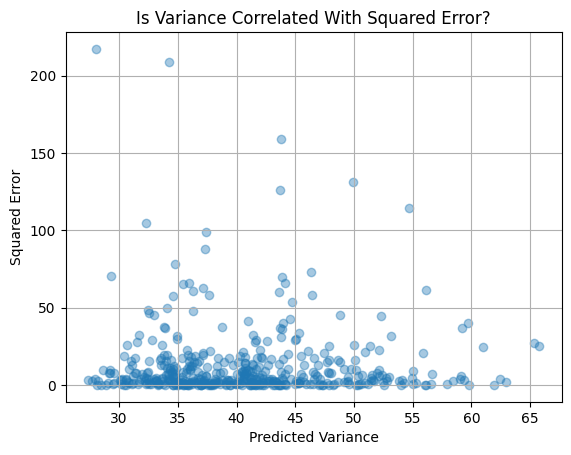

In [57]:

errors = (mu_core_inv - y_test_inv) ** 2

plt.scatter(var_core_inv, errors, alpha=0.4)
plt.xlabel("Predicted Variance")
plt.ylabel("Squared Error")
plt.title("Is Variance Correlated With Squared Error?")
plt.grid(True)
plt.show()

# Plotting from the dictionary as per our need metrices

In [61]:
#New Font size increased version ...

def plot_multiple_metrics_vs_coreset(
    results,
    coreset_percents,
    algos,
    metrics_info,
    full_gpr_metrics,
    output_filename="metrics_vs_coreset.pdf",
    layout='horizontal'
):
    """
    results: dict with metrics for each algo at each coreset size
    coreset_percents: list of coreset % [2, 4, 6, 8, 10]
    algos: list of method names (excluding full GPR)
    metrics_info: list of (metric_name, ylabel, title)
    full_gpr_metrics: dict like {'rmse': value, 'nlpd': value, 'smse': value}
    output_filename: PDF file to save
    layout: 'horizontal' (1 row) or 'vertical' (1 column)
    """
    n_metrics = len(metrics_info)
    if layout == 'horizontal':
        fig, axes = plt.subplots(1, n_metrics, figsize=(5.5 * n_metrics, 4))
    else:
        fig, axes = plt.subplots(n_metrics, 1, figsize=(6, 4 * n_metrics))

    if n_metrics == 1:
        axes = [axes]

    for ax, (metric_name, ylabel, title) in zip(axes, metrics_info):
        key = f"algo_{metric_name}"
        err_key = f"algo_{metric_name}_err"

        metric_vals = np.array(results[key])  # shape: [n_algos, n_points]
        metric_errs = np.array(results.get(err_key, np.zeros_like(metric_vals)))

        # Plot each algorithm’s curve
        for i, algo in enumerate(algos):
            ax.errorbar(
                coreset_percents,
                metric_vals[i],
                yerr=metric_errs[i],
                label=algo,
                marker='o',
                capsize=4,
                linestyle='-',
                markersize=6,
                linewidth=2
            )

        # Plot Full GPR baseline as horizontal line
        baseline = full_gpr_metrics.get(metric_name)
        if baseline is not None:
            ax.axhline(
                y=baseline,
                color='black',
                linestyle='--',
                linewidth=2,
                label="Full GPR"
            )

        ax.set_xlabel("Sample Size in (%) of Full Data", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.set_title(title, fontsize=15)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Create single legend on top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(algos) + 1, frameon=False, fontsize=12)

    # Adjust layout to leave space for legend
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    # Save as PDF
    plt.savefig(output_filename, bbox_inches='tight')
    print(f"Saved plot to {output_filename}")
    plt.show()

Saved plot to Airfoil_Mean_Variance_RMSE_Fixed_Noise05_Matern_15vega_Final.pdf


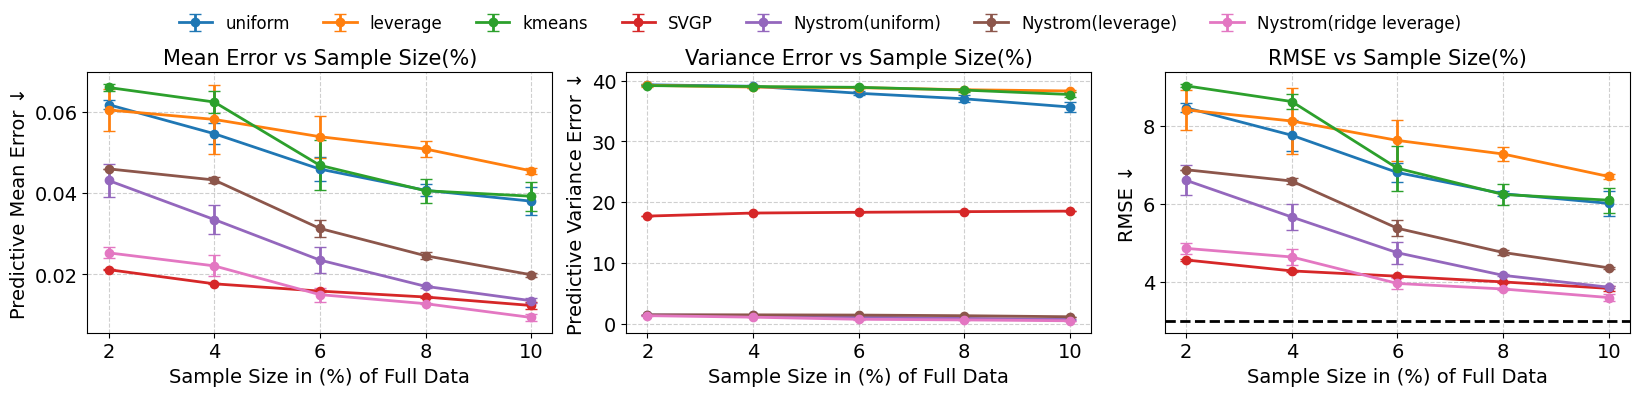

In [64]:
#Final Plot 1 Airfoil Dataset For Paper

algo_names = ["uniform", "leverage", "kmeans", "SVGP","Nystrom(uniform)", "Nystrom(leverage)", "Nystrom(ridge leverage)"]
algos = algo_names

metrics_info = [
    ("mean", "Predictive Mean Error ↓", "Mean Error vs Sample Size(%)"),
    ("variance", "Predictive Variance Error ↓", "Variance Error vs Sample Size(%)"),
    ("rmse", "RMSE ↓", "RMSE vs Sample Size(%)")
]

# Full GPR metric values (baseline for horizontal line)
full_gpr_metrics = {
    "mean": None,
    "variance": None,
    "rmse": rmse
}

plot_multiple_metrics_vs_coreset(
    results=results,
    coreset_percents=coreset_percents,
    algos=algos,
    metrics_info=metrics_info,
    full_gpr_metrics=full_gpr_metrics,
    output_filename="Airfoil_Mean_Variance_RMSE_Fixed_Noise05_Matern_15vega_Final.pdf",
    layout='horizontal'  # or 'vertical'
)


Saved plot to Airfoil_Mean_Variance_NLPD_Fixed_Noise05_Matern_15vega_Final.pdf


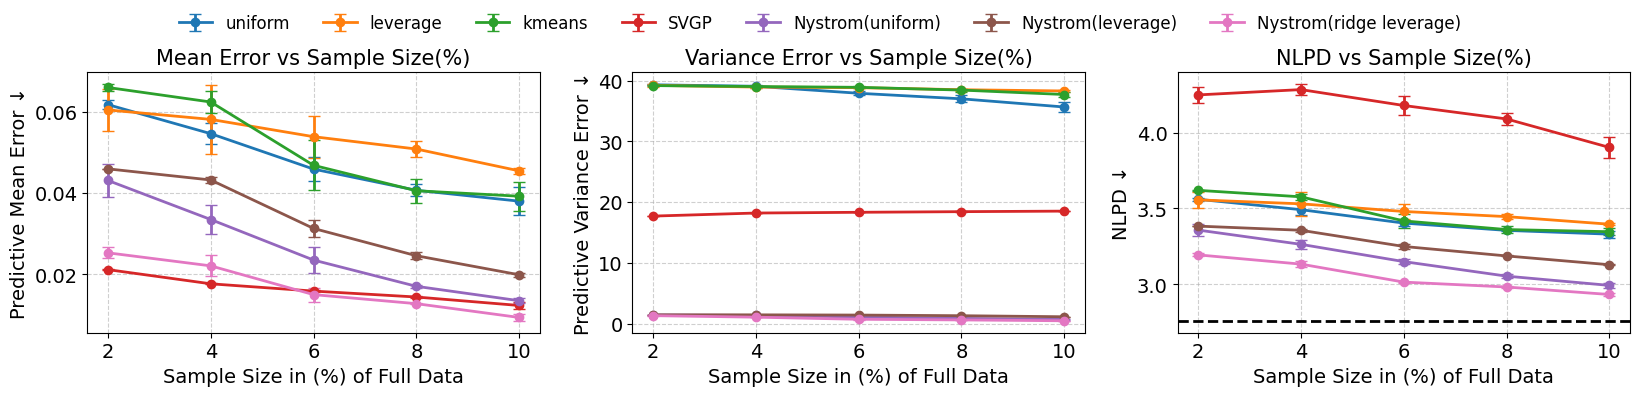

In [65]:
#Final Plot 2 Airfoil Dataset For Paper


metrics_info = [
    ("mean", "Predictive Mean Error ↓", "Mean Error vs Sample Size(%)"),
    ("variance", "Predictive Variance Error ↓", "Variance Error vs Sample Size(%)"),
    ("nlpd", "NLPD ↓", "NLPD vs Sample Size(%)")
]

# Full GPR metric values (baseline for horizontal line)
full_gpr_metrics = {
    "mean": None,
    "variance": None,
    "nlpd": nlpd
}

plot_multiple_metrics_vs_coreset(
    results=results,
    coreset_percents=coreset_percents,
    algos=algos,
    metrics_info=metrics_info,
    full_gpr_metrics=full_gpr_metrics,
    output_filename="Airfoil_Mean_Variance_NLPD_Fixed_Noise05_Matern_15vega_Final.pdf",
    layout='horizontal'  # or 'vertical'
)
 

# Main Latex Table Generator

In [ ]:
#\usepackage{booktabs}
#\usepackage{amsmath}

In [4]:
def format_custom_latex_table(
    coreset_percents,
    selected_algos,
    results,
    all_algos,
    metric_keys,
    metric_labels=None,
    caption="Custom Metric Table",
    label="tab:custom_metrics",
    highlight_best=True,
    bold_all_close=True,
    highlight_threshold=1e-4
):
    if metric_labels is None:
        metric_labels = [key.replace("algo_", "").upper() for key in metric_keys]

    selected_indices = [all_algos.index(algo) for algo in selected_algos]
    num_metrics = len(metric_keys)

    header = "\\begin{table}[ht]\n\\centering\n"
    header += f"\\caption{{{caption}}}\n"
    header += f"\\label{{{label}}}\n"
    header += "\\begin{tabular}{l" + "c" * (1 + num_metrics) + "}\n"
    header += "\\toprule\n"
    header += "\\textbf{Method} & \\textbf{Coreset \\%} & " + " & ".join([f"\\textbf{{{label}}}" for label in metric_labels]) + " \\\\\n"
    header += "\\midrule\n"

    body = ""
    for j, perc in enumerate(coreset_percents):
        # Compute best (minimum) values for this coreset size
        best_vals = []
        for key in metric_keys:
            vals_at_j = [results[key][i][j] for i in selected_indices]
            best_vals.append(min(vals_at_j))

        for algo_idx, algo in zip(selected_indices, selected_algos):
            method = algo.replace('_', '\\_').capitalize() #if j == 0 else ""
            row = f"{method} & {perc}\\%"

            for k, key in enumerate(metric_keys):
                val = results[key][algo_idx][j]
                err = results[f"{key}_err"][algo_idx][j]

                # Bold if it's the best (or very close to best)
                if highlight_best and (val <= best_vals[k] + highlight_threshold):
                    row += f" & $\\mathbf{{{val:.4f}}} \\pm \\mathbf{{{err:.4f}}}$"
                else:
                    row += f" & ${val:.4f} \\pm {err:.4f}$"

            row += " \\\\\n"
            body += row
        body += "\\midrule\n"

    footer = "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
    return header + body + footer

In [9]:
selected_algos = ["uniform", "leverage", "kmeans", "SVGP","Nystrom(uniform)", "Nystrom(leverage)", "Nystrom(ridge leverage)"] 
selected_metrics = ["algo_nlpd", "algo_time", "algo_mem"]
metric_labels = ["NLPD", "Time (s)", "Memory (MB)"]  # Optional pretty labels

latex = format_custom_latex_table(
    coreset_percents=coreset_percents,
    selected_algos=selected_algos,
    results=results,
    all_algos=selected_algos,
    metric_keys=selected_metrics,
    metric_labels=metric_labels,
    caption="Comparison of NLPD, Time (s) and Memory (MB) for GPR methods Airfoil dataset matern kernel.",
    label="tab:nlpd_time_mem"
)

print(latex)

\begin{table}[ht]
\centering
\caption{Comparison of NLPD, Time (s) and Memory (MB) for GPR methods Airfoil dataset matern kernel.}
\label{tab:nlpd_time_mem}
\begin{tabular}{lcccc}
\toprule
\textbf{Method} & \textbf{Coreset \%} & \textbf{NLPD} & \textbf{Time (s)} & \textbf{Memory (MB)} \\
\midrule
Uniform & 2\% & $3.5604 \pm 0.0109$ & $1.5584 \pm 0.0592$ & $27.5898 \pm 4.1839$ \\
Leverage & 2\% & $3.5564 \pm 0.0527$ & $1.5169 \pm 0.0048$ & $25.6128 \pm 0.0925$ \\
Kmeans & 2\% & $3.6192 \pm 0.0046$ & $\mathbf{1.5034} \pm \mathbf{0.0066}$ & $24.5659 \pm 0.0932$ \\
Svgp & 2\% & $4.2478 \pm 0.0553$ & $14.5262 \pm 0.0603$ & $\mathbf{22.3298} \pm \mathbf{0.5513}$ \\
Nystrom(uniform) & 2\% & $3.3576 \pm 0.0369$ & $4.4783 \pm 0.0205$ & $23.2031 \pm 0.0932$ \\
Nystrom(leverage) & 2\% & $3.3837 \pm 0.0000$ & $4.6335 \pm 0.1580$ & $26.0838 \pm 0.3768$ \\
Nystrom(ridge leverage) & 2\% & $\mathbf{3.1941} \pm \mathbf{0.0104}$ & $4.6294 \pm 0.0227$ & $23.5457 \pm 0.3768$ \\
\midrule
Uniform & 4\% & $3